<a href="https://colab.research.google.com/github/SANGRAMLEMBE/100_days_of_ML/blob/main/Day36_Handling_Missing_Data/Handling_Missing_Data_Numerical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [3]:
df  = pd.read_csv("titanic_toy.csv")
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [5]:
df.isnull().mean()  # percentage of missing data

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [6]:
x = df.drop(columns = ['Survived'])

In [7]:
y = df['Survived']

In [8]:
x_train , x_test, y_train , y_test = train_test_split(x,y,test_size=0.2, random_state = 2)


In [9]:
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [10]:
x_train.isnull().mean()

,0
Age,0.207865
Fare,0.050562
Family,0.000000


In [11]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()
mode_age = x_train['Age'].mode()

mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()
mode_fare = x_train['Fare'].mode()

In [12]:
x_train['Age_median'] = x_train['Age'].fillna(median_age)
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)

x_train['Fare_median'] = x_train['Fare'].fillna(median_fare)
x_train['Fare_mean'] = x_train['Fare'].fillna(mean_fare)

In [13]:
x_train.sample(10)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
17,NaN,13.0000,0,28.75,29.785904,13.0000,13.0000
202,34.0,6.4958,0,34.00,34.000000,6.4958,6.4958
289,22.0,7.7500,0,22.00,22.000000,7.7500,7.7500
483,63.0,9.5875,0,63.00,63.000000,9.5875,9.5875
582,54.0,26.0000,0,54.00,54.000000,26.0000,26.0000
56,21.0,10.5000,0,21.00,21.000000,10.5000,10.5000
695,52.0,13.5000,0,52.00,52.000000,13.5000,13.5000
240,NaN,14.4542,1,28.75,29.785904,14.4542,14.4542
890,32.0,7.7500,0,32.00,32.000000,7.7500,7.7500
398,23.0,10.5000,0,23.00,23.000000,10.5000,10.5000


In [14]:
print('Original Age variable variance:', x_train['Age'].var())
print('Age imputed with median variance:', x_train['Age_median'].var())
print('Age imputed with mean variance:', x_train['Age_mean'].var())

print('Original fare variable varience', x_train['Fare'].var())
print('Fare imputed with median variance:', x_train['Fare_median'].var())
print('Fare imputed with mean variance:', x_train['Fare_mean'].var())

Original Age variable variance: 204.3495133904614
Age imputed with median variance: 161.9895663346054
Age imputed with mean variance: 161.81262452718673
Original fare variable varience 2448.197913706318
Fare imputed with median variance: 2340.0910219753637
Fare imputed with mean variance: 2324.2385256705547


## Here we getting drastic change at mean , because of we added mean values at missing value which is problimatic as it showing much difference

<Axes: ylabel='Density'>

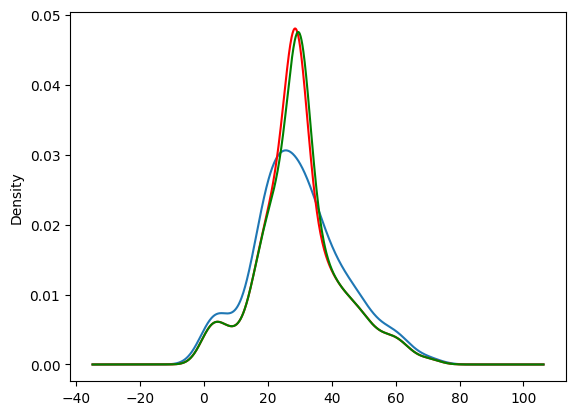

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind = 'kde', ax = ax)
x_train['Age_median'].plot(kind = 'kde', ax = ax, color = 'red')
x_train['Age_mean'].plot(kind = 'kde', ax = ax, color = 'green')

# Here we can see nearly all curves are same

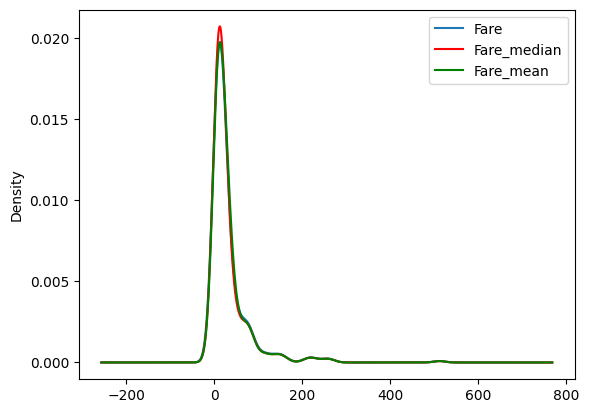

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
x_train['Fare'].plot(kind = 'kde', ax = ax)

# Variable Imputed with the median
x_train['Fare_median'].plot(kind = 'kde', ax = ax, color = 'red')

# variable imputed with mean
x_train['Fare_mean'].plot(kind = 'kde', ax = ax, color = 'green')

# add Legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

In [18]:
# Covariance

x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


In [19]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.090156
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205942,0.205499
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086982,0.089673
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083461,0.086078
Fare_median,0.087356,1.000000,0.205942,0.086982,0.083461,1.000000,0.996607
Fare_mean,0.090156,1.000000,0.205499,0.089673,0.086078,0.996607,1.000000


#Boxplot

## we can see without mean and median we don't have too much Outliers , but in mean and median we can see clearly soo many outliers

- This is not GOOD ---> RED Flag 🚩

<Axes: >

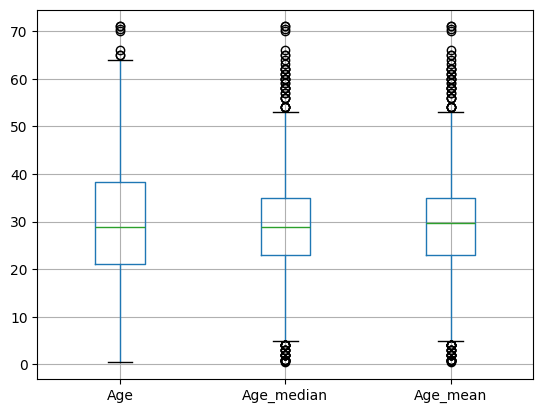

In [21]:
x_train[['Age','Age_median','Age_mean']].boxplot()

# Outliers are looks same in all the cases , mean is not derivats much from original


Green Flag 🚩

<Axes: >

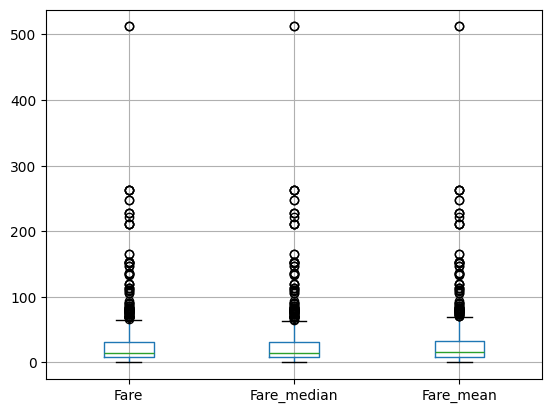

In [24]:
x_train[['Fare','Fare_median','Fare_mean']].boxplot()

# Using Sklearn

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)


In [27]:
imputer1 = SimpleImputer(strategy = 'median')
imputer2 = SimpleImputer(strategy = 'mean')



In [28]:
trf = ColumnTransformer([
    ('median_imputer', imputer1, ['Age']),
    ('mean_imputer', imputer2, ['Fare'])
], remainder = 'passthrough')

In [29]:
trf.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('median_imputer',
                                 SimpleImputer(strategy='median'), ['Age']),
                                ('mean_imputer', SimpleImputer(), ['Fare'])])

In [30]:
trf.named_transformers_['median_imputer'].statistics_

array([28.75])

In [31]:
trf.named_transformers_['mean_imputer'].statistics_

array([32.61759689])

In [32]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [33]:
x_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])